# Multivariate Statistics

For this project I am using the following variables: 

T2: Temperature (at 2m above ground)
* used as a predictor or as the downscaling variable of interest
    
PSFC: Surface Pressure
*  used as a predictor
    
U10: U-component of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
V10: V-compoennet of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
SWDOWN: Global Horizontal Irradiance
* used as a predictor or as the downscaling variable of interest
    
sin_time: 

cos_time:

PBLH: Planetary Boundary Height

In [1]:
import xarray as xr
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [58]:
# Choose the variable you would like to examine:

choices = ['T2', 'PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']

datasets = ['uwrf', 'nam']


# Change the following cell according to the variable and dataset you would like to examine

In [59]:
#Change var and df based on your preference
var = 'T2' 
df = 'uwrf'

if df == 'uwrf':
    data = uwrf_train
    ds = data[var]
elif df == 'nam':
    data = nam_train
    ds = data[var]
else:
    raise ValueError(f"Invalid string: '{df}'. Expected either 'uwrf' or 'nam'.")

In [4]:
data

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [5]:
ds

<xarray.DataArray 'SWDOWN' (time: 2697, y: 120, x: 120)> Size: 155MB
[38836800 values with dtype=float32]
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger:

# Pearson Correlation


Checking for linear relationship between variables.

Correlation values fall into [-1, 1] interval

* 0 = no relationship
* 1 = positive relationship (as x increases, so does y)
* -1 = negative relationship (as x increases, y decreases)

In [75]:
from scipy.stats import pearsonr
other_vars = [x for x in choices if x != var]

corr_table = {}

for i in other_vars:
    
    x = data[var].values.flatten()
    y = data[i].values.flatten()
    
    mask = ~np.isnan(x) & ~np.isnan(y)
    correlation_coefficient, p_value = pearsonr(x[mask], y[mask])

    corr_table[f'{var} vs {i}'] = {
    'Correlation': correlation_coefficient,
    'P-Value': p_value
    }


import pandas as pd

df_corr = pd.DataFrame([
    {'Pair': key, 'Correlation': value['Correlation'], 'P-Value': value['P-Value']}
    for key, value in corr_table.items()
])

print(df_corr)


           Pair  Correlation  P-Value
0    T2 vs PSFC     0.280686      0.0
1     T2 vs U10    -0.182800      0.0
2     T2 vs V10     0.268625      0.0
3  T2 vs SWDOWN     0.197111      0.0
4    T2 vs PBLH     0.081549      0.0


In [63]:
other_vars = [x for x in choices if x != var]

corr_maps = {}

for k in other_vars:
    corr_map = np.full((120, 120), np.nan)
    for i in range(120):
        for j in range(120):
            main_series = data[var][:, i, j].values
            other_series = data[k][:, i, j].values
            mask = ~np.isnan(main_series) & ~np.isnan(other_series)
            if np.sum(mask) > 10:
                corr_map[i, j], _ = pearsonr(main_series[mask], other_series[mask])
    corr_maps[k] = corr_map


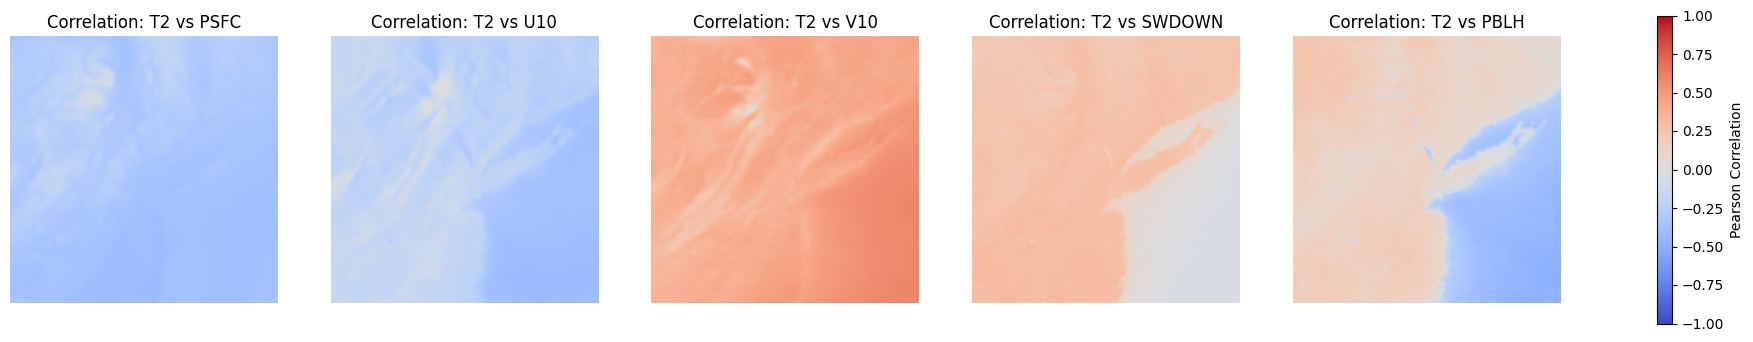

In [66]:
n = len(corr_maps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

for i, (name, cmap) in enumerate(corr_maps.items()):
    ax = axes[i]
    im = ax.imshow(cmap, vmin=-1, vmax=1, cmap='coolwarm', origin='lower')
    ax.set_title(f'Correlation: T2 vs {name}')
    ax.axis('off')

# Add a shared colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Pearson Correlation')

plt.show()


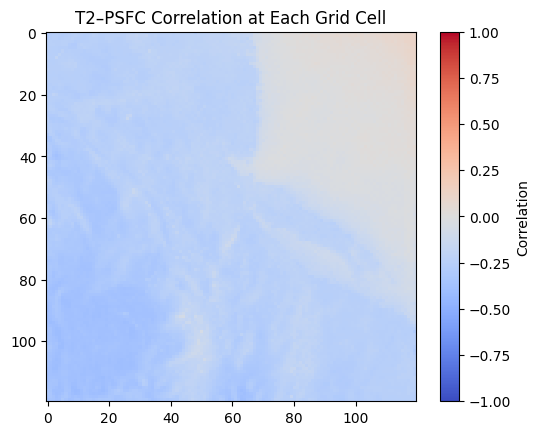

In [52]:
plt.imshow(corr_map, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('T2–PSFC Correlation at Each Grid Cell')
plt.show()


# Regression